In [ ]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery
import pandas as pd
import numpy as np

PROJECT_ID = "f1-analytics-505812"
client = bigquery.Client(project=PROJECT_ID)

query = """
SELECT
    season_year,
    grid_position,
    team_form_5_pos,
    driver_form_5_pos,
    form_race_count,
    is_podium
FROM `f1_analytics.mart_race_results`
WHERE season_year BETWEEN 2003 AND 2024
  AND did_start
"""

ham = client.query(query, location="EU").to_dataframe()

# Form penceresi dolmayan ve eksik kayitlari cikar
d = ham[ham["form_race_count"] >= 5].copy()
d = d.dropna(subset=["grid_position", "team_form_5_pos", "driver_form_5_pos"])

print(f"Kayit sayisi: {len(d)}")
print(f"Podyum orani: %{d['is_podium'].mean()*100:.1f}")

Kayit sayisi: 6328
Podyum orani: %14.8


In [ ]:
egitim = d["season_year"] <= 2016
test   = d["season_year"] >= 2017

print(f"Egitim {egitim.sum()} kayit | podyum %{d.loc[egitim,'is_podium'].mean()*100:.1f}")
print(f"Test   {test.sum()} kayit | podyum %{d.loc[test,'is_podium'].mean()*100:.1f}")

# Baseline'i AYNI test setinde hesapla ki karsilastirma adil olsun
baseline_tahmin = (d.loc[test, "grid_position"] <= 3).astype(int)
gercek = d.loc[test, "is_podium"].astype(int)

print(f"\nBaseline isabet (test setinde): "
      f"%{(baseline_tahmin == gercek).mean()*100:.1f}")

Egitim 3825 kayit | podyum %14.5
Test   2503 kayit | podyum %15.4

Baseline isabet (test setinde): %89.9


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix

print(f"Accuracy : %{accuracy_score(gercek, baseline_tahmin)*100:.1f}")
print(f"Precision: %{precision_score(gercek, baseline_tahmin)*100:.1f}")
print(f"Recall   : %{recall_score(gercek, baseline_tahmin)*100:.1f}")
print(f"F1       : %{f1_score(gercek, baseline_tahmin)*100:.1f}")

# Hicbir sey tahmin etmeyen model
import numpy as np
aptal = np.zeros(len(gercek), dtype=int)
print(f"\n'Hicbiri podyum degil' diyen model accuracy: %{accuracy_score(gercek, aptal)*100:.1f}")

print("\nKarisiklik matrisi:")
tn, fp, fn, tp = confusion_matrix(gercek, baseline_tahmin).ravel()
print(f"  Dogru yakalanan podyum : {tp}")
print(f"  Kacirilan podyum       : {fn}")
print(f"  Yanlis alarm           : {fp}")
print(f"  Dogru elenen           : {tn}")

Accuracy : %89.9
Precision: %67.4
Recall   : %66.8
F1       : %67.1

'Hicbiri podyum degil' diyen model accuracy: %84.6

Karisiklik matrisi:
  Dogru yakalanan podyum : 258
  Kacirilan podyum       : 128
  Yanlis alarm           : 125
  Dogru elenen           : 1992


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

OZELLIKLER = ["grid_position", "team_form_5_pos", "driver_form_5_pos"]

# Hedef degisken: egitim ve test icin ayri ayri
gercek_egitim = d.loc[egitim, "is_podium"].astype(int)
gercek = d.loc[test, "is_podium"].astype(int)

# Olcekleme: grid 1-20, form 1-20 ama farkli dagiliyor.
# Ayni olcege getirmezsek katsayilari karsilastiramayiz.
olcek = StandardScaler().fit(d.loc[egitim, OZELLIKLER])

model = LogisticRegression(max_iter=1000)
model.fit(olcek.transform(d.loc[egitim, OZELLIKLER]), gercek_egitim)

# Model her satir icin bir OLASILIK uretiyor: "bu surucu podyum yapar mi?"
olasilik = model.predict_proba(olcek.transform(d.loc[test, OZELLIKLER]))[:, 1]
tahmin = (olasilik >= 0.5).astype(int)

print(f"Accuracy : %{accuracy_score(gercek, tahmin)*100:.1f}")
print(f"Precision: %{precision_score(gercek, tahmin)*100:.1f}")
print(f"Recall   : %{recall_score(gercek, tahmin)*100:.1f}")
print(f"F1       : %{f1_score(gercek, tahmin)*100:.1f}")

Accuracy : %89.5
Precision: %67.7
Recall   : %60.9
F1       : %64.1


In [ ]:
print(f"{'Esik':>6} {'Precision':>10} {'Recall':>8} {'F1':>7} {'Kac tahmin':>12}")
for esik in [0.50, 0.45, 0.405, 0.40, 0.35, 0.30]:
    t = (olasilik >= esik).astype(int)
    print(f"{esik:6.2f} {precision_score(gercek,t)*100:9.1f} "
          f"{recall_score(gercek,t)*100:8.1f} {f1_score(gercek,t)*100:7.1f} {t.sum():12d}")

print(f"\nBaseline: P %67.4 | R %66.8 | F1 %67.1 | 383 tahmin")
print(f"Test setindeki gercek podyum sayisi: {gercek.sum()}")

  Esik  Precision   Recall      F1   Kac tahmin
  0.50      67.7     60.9    64.1          347
  0.45      65.4     67.1    66.2          396
  0.41      64.4     75.9    69.7          455
  0.40      64.1     76.2    69.6          459
  0.35      60.0     79.0    68.2          508
  0.30      56.4     83.2    67.2          569

Baseline: P %67.4 | R %66.8 | F1 %67.1 | 383 tahmin
Test setindeki gercek podyum sayisi: 386


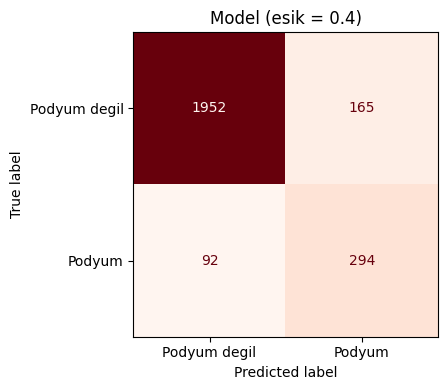

                          Model   Baseline
Yakalanan podyum            294        258
Kacirilan podyum             92        128
Yanlis alarm                165        125

Katsayilar:
grid_position       -1.964
team_form_5_pos     -0.430
driver_form_5_pos   -0.625


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

SECILEN_ESIK = 0.40

tahmin = (olasilik >= SECILEN_ESIK).astype(int)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    gercek, tahmin, display_labels=["Podyum degil", "Podyum"],
    cmap="Reds", ax=ax, colorbar=False)
ax.set_title(f"Model (esik = {SECILEN_ESIK})")
plt.tight_layout(); plt.show()

tn, fp, fn, tp = confusion_matrix(gercek, tahmin).ravel()
tn2, fp2, fn2, tp2 = confusion_matrix(gercek, baseline_tahmin).ravel()

print(f"{'':22s} {'Model':>8} {'Baseline':>10}")
print(f"{'Yakalanan podyum':22s} {tp:8d} {tp2:10d}")
print(f"{'Kacirilan podyum':22s} {fn:8d} {fn2:10d}")
print(f"{'Yanlis alarm':22s} {fp:8d} {fp2:10d}")

print("\nKatsayilar:")
katsayilar = pd.Series(model.coef_[0], index=OZELLIKLER)
print(katsayilar.round(3).to_string())

<Figure size 640x480 with 0 Axes>

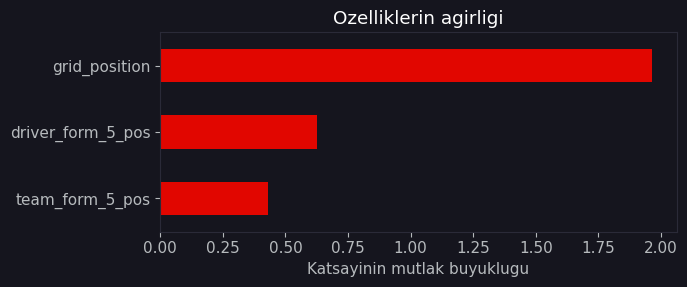

In [ ]:
# Karisiklik matrisi hucresinin sonuna ekle
plt.savefig("karisiklik_matrisi.png", dpi=150, bbox_inches="tight")

# Katsayi grafigi
fig, ax = plt.subplots(figsize=(7, 3))
katsayilar.abs().sort_values().plot(kind="barh", color="#E10600", ax=ax)
ax.set_xlabel("Katsayinin mutlak buyuklugu")
ax.set_title("Ozelliklerin agirligi")
plt.tight_layout()
plt.savefig("katsayilar.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt

KIRMIZI = "#E10600"
GRI     = "#4A4A57"
YUZEY   = "#25252F"
BEYAZ   = "#FFFFFF"
SOLUK   = "#8E8E9B"

mpl.rcParams.update({
    "figure.facecolor":   "none",
    "axes.facecolor":     "none",
    "savefig.facecolor":  "none",
    "text.color":         BEYAZ,
    "axes.labelcolor":    SOLUK,
    "xtick.color":        SOLUK,
    "ytick.color":        SOLUK,
    "axes.edgecolor":     "#2A2A38",
    "font.size":          11,
    "axes.titlesize":     13,
    "axes.titleweight":   "medium",
    "axes.titlelocation": "left",
})

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score,
)

# F1 koyu tema renkleri — Power BI temasiyla ayni
BG      = "#15151E"   # sayfa zemini
KART    = "#1E1E2A"   # kart zemini
CIZGI   = "#2A2A38"   # kenarlik / izgara
BEYAZ   = "#FFFFFF"
GRI     = "#B6BABD"   # ikincil metin
SOLUK   = "#7A7F87"   # ucuncul metin
KIRMIZI = "#E10600"   # F1 kirmizisi
MAVI    = "#5FD7FF"
TURUNCU = "#FF8000"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": BEYAZ,
    "axes.labelcolor": GRI,
    "xtick.color": GRI,
    "ytick.color": GRI,
    "axes.edgecolor": CIZGI,
    "grid.color": CIZGI,
    "font.family": "DejaVu Sans",
    "font.size": 11,
})

# Model bolumunde sectigin esik
SECILEN_ESIK = 0.40

# Baseline'in test setindeki F1 degeri (esik grafigindeki referans cizgisi)
BASELINE_F1 = f1_score(gercek, baseline_tahmin) * 100

tahmin = (olasilik >= SECILEN_ESIK).astype(int)

print(f"Esik {SECILEN_ESIK} ile {tahmin.sum()} kez 'podyum' tahmini yapildi.")

Esik 0.4 ile 459 kez 'podyum' tahmini yapildi.


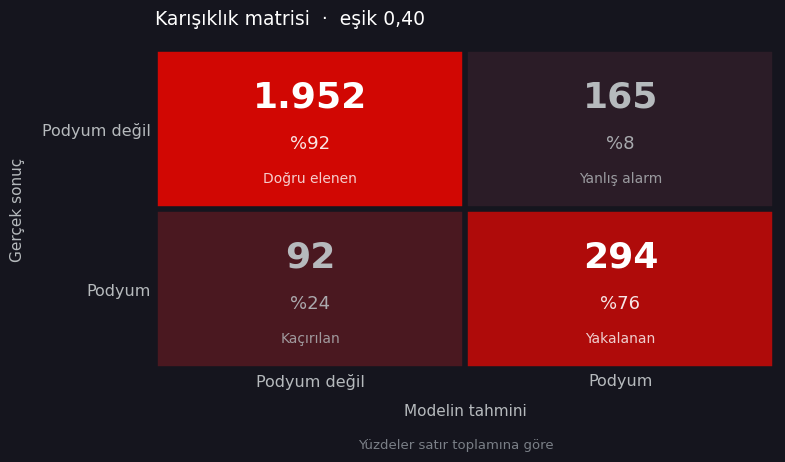

In [ ]:
cm = confusion_matrix(gercek, tahmin)
oran = cm / cm.sum(axis=1, keepdims=True) * 100

cmap = LinearSegmentedColormap.from_list("f1", [KART, "#7A1216", KIRMIZI])

fig, ax = plt.subplots(figsize=(8.0, 4.7))
ax.imshow(oran, cmap=cmap, vmin=0, vmax=100)

etiketler = ["Podyum değil", "Podyum"]
ax.set_xticks([0, 1]); ax.set_xticklabels(etiketler, fontsize=11.5)
ax.set_yticks([0, 1]); ax.set_yticklabels(etiketler, fontsize=11.5)
ax.set_xlabel("Modelin tahmini", fontsize=11, labelpad=12)
ax.set_ylabel("Gerçek sonuç", fontsize=11, labelpad=12)
ax.set_title(f"Karışıklık matrisi  ·  eşik {SECILEN_ESIK:.2f}".replace(".", ","),
             fontsize=13.5, color=BEYAZ, pad=18, loc="left")

aciklama = [["Doğru elenen", "Yanlış alarm"],
            ["Kaçırılan",    "Yakalanan"]]

for i in range(2):
    for j in range(2):
        renk = BEYAZ if oran[i, j] > 45 else GRI
        ax.text(j, i - 0.20, f"{cm[i, j]:,}".replace(",", "."),
                ha="center", va="center", fontsize=26, fontweight="bold", color=renk)
        ax.text(j, i + 0.09, f"%{oran[i, j]:.0f}",
                ha="center", va="center", fontsize=13, color=renk, alpha=0.9)
        ax.text(j, i + 0.31, aciklama[i][j],
                ha="center", va="center", fontsize=10, color=renk, alpha=0.8)

for s in ax.spines.values():
    s.set_visible(False)
ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
ax.grid(which="minor", color=BG, linewidth=4)
ax.tick_params(which="minor", length=0)
ax.tick_params(length=0)
ax.imshow(oran, cmap=cmap, vmin=0, vmax=100, aspect="auto")

fig.subplots_adjust(bottom=0.20)
ax.set_xlabel("Modelin tahmini", fontsize=11, labelpad=10)   # labelpad 12 → 10
fig.text(0.5, 0.03, "Yüzdeler satır toplamına göre",
         ha="center", fontsize=9.5, color=SOLUK)
# plt.tight_layout() satırını da kaldır — subplots_adjust ile çakışıyor
plt.savefig("model_karisiklik_matrisi.png", dpi=200, facecolor=BG)
plt.show()

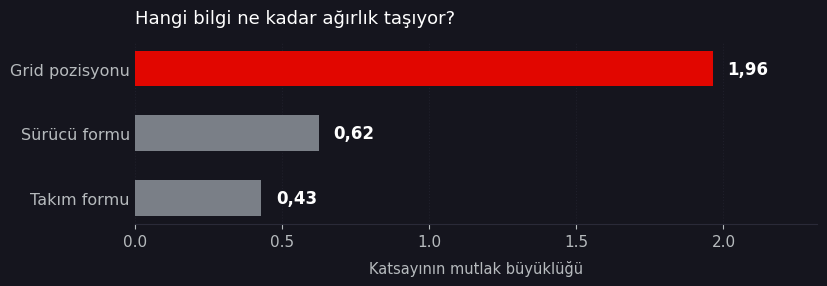

Grid'in agirligi, iki form degiskeninin toplaminin 1.9 kati


In [ ]:
ISIM = {
    "grid_position":     "Grid pozisyonu",
    "driver_form_5_pos": "Sürücü formu",
    "team_form_5_pos":   "Takım formu",
}

k = pd.Series(model.coef_[0], index=OZELLIKLER).abs().sort_values()

fig, ax = plt.subplots(figsize=(8.4, 3.0))
renkler = [SOLUK] * (len(k) - 1) + [KIRMIZI]   # en buyugu kirmizi
cubuklar = ax.barh([ISIM.get(i, i) for i in k.index], k.values,
                   color=renkler, height=0.55)

for cb, v in zip(cubuklar, k.values):
    ax.text(v + 0.05, cb.get_y() + cb.get_height() / 2, f"{v:.2f}".replace(".", ","),
            va="center", fontsize=12, fontweight="bold", color=BEYAZ)

ax.set_xlim(0, k.max() * 1.18)
ax.set_xlabel("Katsayının mutlak büyüklüğü", fontsize=10.5, labelpad=8)
ax.set_title("Hangi bilgi ne kadar ağırlık taşıyor?",
             fontsize=13, color=BEYAZ, pad=14, loc="left")
ax.xaxis.grid(True, linestyle=":", alpha=0.5)
ax.set_axisbelow(True)
ax.tick_params(axis="y", labelsize=11.5, length=0)

for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(CIZGI)

plt.tight_layout()
plt.savefig("model_katsayilar.png", dpi=200, bbox_inches="tight", facecolor=BG)
plt.show()

oran_metni = abs(k.iloc[-1]) / abs(k.iloc[:-1]).sum()
print(f"Grid'in agirligi, iki form degiskeninin toplaminin {oran_metni:.1f} kati")

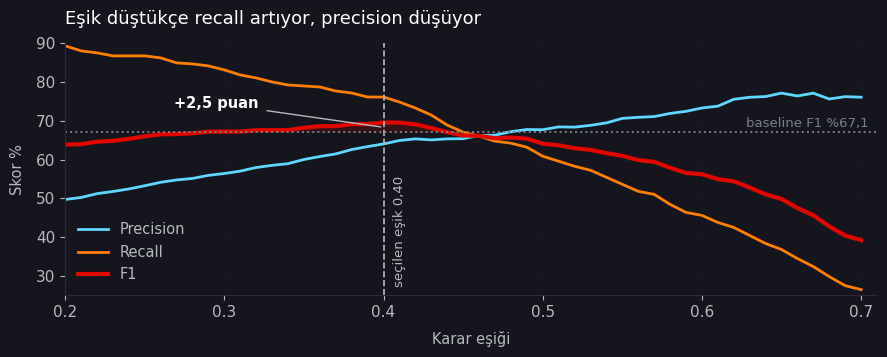

In [ ]:
# ======================================================================
# 3. ESIK TARAMASI   (Power BI kutusu 610×250 → oran 2,44)
# ======================================================================
BASELINE_F1 = f1_score(gercek, baseline_tahmin) * 100
MODEL_F1    = f1_score(gercek, (olasilik >= SECILEN_ESIK).astype(int)) * 100
FARK        = MODEL_F1 - BASELINE_F1

esikler = np.arange(0.20, 0.71, 0.01)
P = [precision_score(gercek, (olasilik >= t).astype(int), zero_division=0) * 100 for t in esikler]
R = [recall_score(gercek,    (olasilik >= t).astype(int), zero_division=0) * 100 for t in esikler]
F = np.array([f1_score(gercek, (olasilik >= t).astype(int), zero_division=0) * 100 for t in esikler])

fig, ax = plt.subplots(figsize=(9.0, 3.7))

# modelin baseline'i gectigi band
ax.fill_between(esikler, BASELINE_F1, F, where=(F > BASELINE_F1),
                color=KIRMIZI, alpha=0.16, interpolate=True, linewidth=0)

ax.plot(esikler, P, color=MAVI,    lw=2, label="Precision")
ax.plot(esikler, R, color=TURUNCU, lw=2, label="Recall")
ax.plot(esikler, F, color=KIRMIZI, lw=3, label="F1")

ax.axvline(SECILEN_ESIK, color=GRI,   ls="--", lw=1.2)
ax.axhline(BASELINE_F1,  color=SOLUK, ls=":",  lw=1.4)

# secilen esikteki farki isaretle
ax.annotate(f"+{FARK:.1f} puan".replace(".", ","),
            xy=(SECILEN_ESIK, (MODEL_F1 + BASELINE_F1) / 2),
            xytext=(0.295, 74.5),
            color=BEYAZ, fontsize=10.5, fontweight="bold",
            ha="center", va="center",
            arrowprops=dict(arrowstyle="-", color=GRI, lw=1, shrinkA=4, shrinkB=2))

ax.text(SECILEN_ESIK + 0.006, 27, f"seçilen eşik {SECILEN_ESIK:.2f}".replace(".", ","),
        color=GRI, fontsize=9.5, rotation=90, va="bottom")
ax.text(0.705, BASELINE_F1 + 1.4, f"baseline F1 %{BASELINE_F1:.1f}".replace(".", ","),
        color=SOLUK, fontsize=9.5, ha="right")

ax.set_xlabel("Karar eşiği", fontsize=10.5, labelpad=8)
ax.set_ylabel("Skor %", fontsize=10.5, labelpad=8)
ax.set_title("Eşik düştükçe recall artıyor, precision düşüyor",
             fontsize=13, color=BEYAZ, pad=14, loc="left")
ax.grid(True, linestyle=":", alpha=0.45)
ax.set_axisbelow(True)
ax.set_xlim(0.20, 0.71)
ax.set_ylim(25, 90)

lg = ax.legend(frameon=False, fontsize=10.5, loc="lower left")
for t in lg.get_texts():
    t.set_color(GRI)

for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
for s in ["bottom", "left"]:
    ax.spines[s].set_color(CIZGI)

plt.tight_layout()
plt.savefig("model_esik_taramasi.png", dpi=200, facecolor=BG)
plt.show()

In [ ]:
from google.colab import files

for dosya in ["model_karisiklik_matrisi.png",
              ]:
    files.download(dosya)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar

y = np.asarray(gercek)
m = np.asarray((olasilik >= 0.40).astype(int))
b = np.asarray(baseline_tahmin)

model_dogru, base_dogru = (m == y), (b == y)
tablo = [[int(( model_dogru &  base_dogru).sum()), int(( model_dogru & ~base_dogru).sum())],
         [int((~model_dogru &  base_dogru).sum()), int((~model_dogru & ~base_dogru).sum())]]

print(tablo)
print(mcnemar(tablo, exact=False, correction=True))

[[2166, 80], [84, 173]]
pvalue      0.8147826383183654
statistic   0.054878048780487805


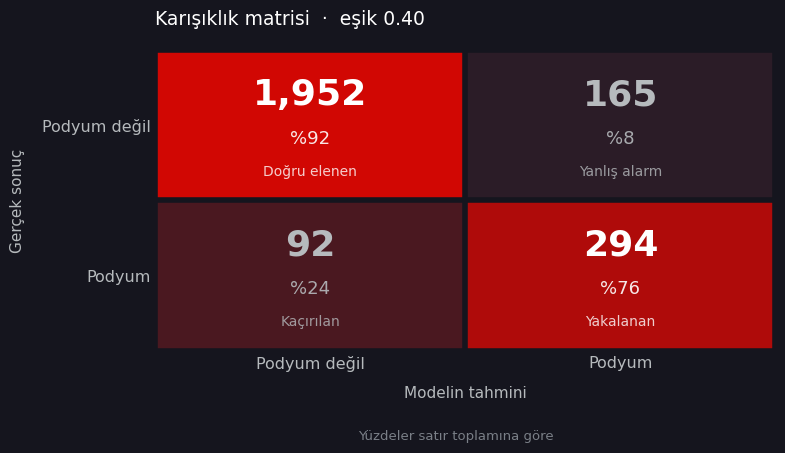

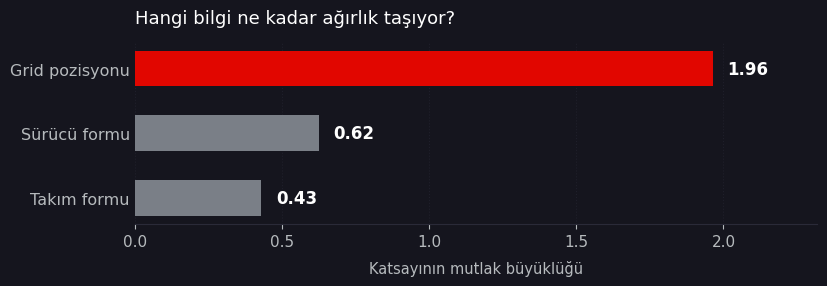

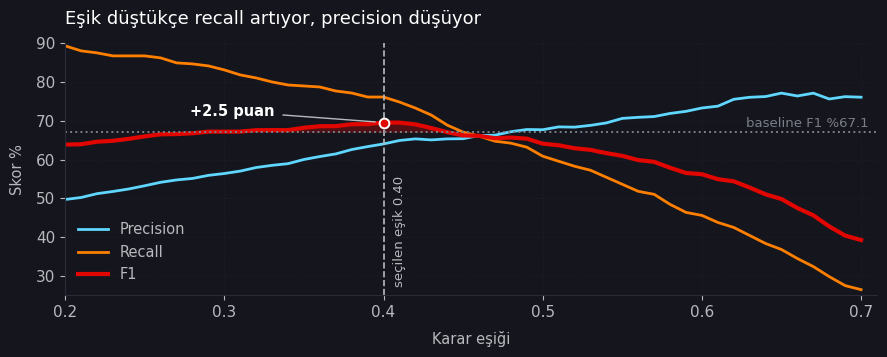

Uc gorsel kaydedildi. Baseline F1 %67.1 · Model F1 %69.6 · fark +2.5 puan


In [ ]:
# F1 Koyu Tema — Model Görselleri (Colab)
#
# Bu hucreyi model kurulduktan SONRA calistir.
# Gerekli degiskenler: model, olcek, d, egitim, test, OZELLIKLER, olasilik,
#                      gercek, baseline_tahmin

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score,
)

# ----------------------------------------------------------------------
# F1 koyu tema renkleri
# ----------------------------------------------------------------------
BG      = "#15151E"   # sayfa zemini
KART    = "#1E1E2A"   # kart zemini
CIZGI   = "#2A2A38"   # kenarlik / izgara
BEYAZ   = "#FFFFFF"
GRI     = "#B6BABD"   # ikincil metin
SOLUK   = "#7A7F87"   # ucuncul metin
KIRMIZI = "#E10600"   # F1 kirmizisi
MAVI    = "#5FD7FF"
TURUNCU = "#FF8000"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": BEYAZ,
    "axes.labelcolor": GRI,
    "xtick.color": GRI,
    "ytick.color": GRI,
    "axes.edgecolor": CIZGI,
    "grid.color": CIZGI,
    "font.family": "DejaVu Sans",
    "font.size": 11,
})

SECILEN_ESIK = 0.40
tahmin = (olasilik >= SECILEN_ESIK).astype(int)


# ======================================================================
# 1. KARISIKLIK MATRISI          (Power BI kutusu 610×358 → oran 1.70)
# ======================================================================
cm = confusion_matrix(gercek, tahmin)
oran = cm / cm.sum(axis=1, keepdims=True) * 100   # satir bazinda yuzde

cmap = LinearSegmentedColormap.from_list("f1", [KART, "#7A1216", KIRMIZI])

fig, ax = plt.subplots(figsize=(8.0, 4.7))
ax.imshow(oran, cmap=cmap, vmin=0, vmax=100, aspect="auto")

etiketler = ["Podyum değil", "Podyum"]
ax.set_xticks([0, 1]); ax.set_xticklabels(etiketler, fontsize=11.5)
ax.set_yticks([0, 1]); ax.set_yticklabels(etiketler, fontsize=11.5)
ax.set_xlabel("Modelin tahmini", fontsize=11, labelpad=10)
ax.set_ylabel("Gerçek sonuç", fontsize=11, labelpad=12)
ax.set_title(f"Karışıklık matrisi  ·  eşik {SECILEN_ESIK:.2f}",
             fontsize=13.5, color=BEYAZ, pad=18, loc="left")

aciklama = [["Doğru elenen", "Yanlış alarm"],
            ["Kaçırılan",    "Yakalanan"]]

for i in range(2):
    for j in range(2):
        renk = BEYAZ if oran[i, j] > 45 else GRI
        ax.text(j, i - 0.20, f"{cm[i, j]:,}",
                ha="center", va="center", fontsize=26, fontweight="bold", color=renk)
        ax.text(j, i + 0.09, f"%{oran[i, j]:.0f}",
                ha="center", va="center", fontsize=13, color=renk, alpha=0.9)
        ax.text(j, i + 0.31, aciklama[i][j],
                ha="center", va="center", fontsize=10, color=renk, alpha=0.8)

for s in ax.spines.values():
    s.set_visible(False)
ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
ax.grid(which="minor", color=BG, linewidth=4)
ax.tick_params(which="minor", length=0)
ax.tick_params(length=0)

# Alt not figurun ICINDE — kesilmiyor, x etiketiyle cakismiyor
fig.subplots_adjust(top=0.86, bottom=0.22)
fig.text(0.5, 0.03, "Yüzdeler satır toplamına göre",
         ha="center", fontsize=9.5, color=SOLUK)

plt.savefig("model_karisiklik_matrisi.png", dpi=200, facecolor=BG)
plt.show()


# ======================================================================
# 2. KATSAYILAR                  (Power BI kutusu 610×218 → oran 2.80)
# ======================================================================
ISIM = {
    "grid_position":     "Grid pozisyonu",
    "driver_form_5_pos": "Sürücü formu",
    "team_form_5_pos":   "Takım formu",
}

k = pd.Series(model.coef_[0], index=OZELLIKLER).abs().sort_values()

fig, ax = plt.subplots(figsize=(8.4, 3.0))
renkler = [SOLUK] * (len(k) - 1) + [KIRMIZI]     # en buyugu kirmizi
cubuklar = ax.barh([ISIM[i] for i in k.index], k.values, color=renkler, height=0.55)

for c, v in zip(cubuklar, k.values):
    ax.text(v + 0.05, c.get_y() + c.get_height() / 2, f"{v:.2f}",
            va="center", fontsize=12, fontweight="bold", color=BEYAZ)

ax.set_xlim(0, k.max() * 1.18)
ax.set_xlabel("Katsayının mutlak büyüklüğü", fontsize=10.5, labelpad=8)
ax.set_title("Hangi bilgi ne kadar ağırlık taşıyor?",
             fontsize=13, color=BEYAZ, pad=14, loc="left")
ax.xaxis.grid(True, linestyle=":", alpha=0.5)
ax.set_axisbelow(True)
ax.tick_params(axis="y", labelsize=11.5, length=0)

for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(CIZGI)

plt.tight_layout()
plt.savefig("model_katsayilar.png", dpi=200, facecolor=BG)
plt.show()


# ======================================================================
# 3. ESIK TARAMASI               (Power BI kutusu 610×250 → oran 2.44)
# ======================================================================
BASELINE_F1 = f1_score(gercek, baseline_tahmin) * 100
MODEL_F1    = f1_score(gercek, (olasilik >= SECILEN_ESIK).astype(int)) * 100
FARK        = MODEL_F1 - BASELINE_F1

esikler = np.arange(0.20, 0.71, 0.01)
P = [precision_score(gercek, (olasilik >= t).astype(int), zero_division=0) * 100 for t in esikler]
R = [recall_score(gercek,    (olasilik >= t).astype(int), zero_division=0) * 100 for t in esikler]
F = np.array([f1_score(gercek, (olasilik >= t).astype(int), zero_division=0) * 100 for t in esikler])

fig, ax = plt.subplots(figsize=(9.0, 3.7))

# modelin baseline'i gectigi band
ax.fill_between(esikler, BASELINE_F1, F, where=(F > BASELINE_F1),
                color=KIRMIZI, alpha=0.30, interpolate=True, linewidth=0)

ax.plot(esikler, P, color=MAVI,    lw=2, label="Precision")
ax.plot(esikler, R, color=TURUNCU, lw=2, label="Recall")
ax.plot(esikler, F, color=KIRMIZI, lw=3, label="F1")

ax.axvline(SECILEN_ESIK, color=GRI,   ls="--", lw=1.2)
ax.axhline(BASELINE_F1,  color=SOLUK, ls=":",  lw=1.4)

# F1 tepe noktasi + fark etiketi
ax.plot([SECILEN_ESIK], [MODEL_F1], "o", color=KIRMIZI, ms=7,
        mec=BEYAZ, mew=1.4, zorder=5)
ax.annotate(f"+{FARK:.1f} puan",
            xy=(SECILEN_ESIK, MODEL_F1),
            xytext=(0.305, 72.5),
            color=BEYAZ, fontsize=10.5, fontweight="bold",
            ha="center", va="center",
            arrowprops=dict(arrowstyle="-", color=GRI, lw=1, shrinkA=4, shrinkB=6))

ax.text(SECILEN_ESIK + 0.006, 27, f"seçilen eşik {SECILEN_ESIK:.2f}",
        color=GRI, fontsize=9.5, rotation=90, va="bottom")
ax.text(0.705, BASELINE_F1 + 1.4, f"baseline F1 %{BASELINE_F1:.1f}",
        color=SOLUK, fontsize=9.5, ha="right")

ax.set_xlabel("Karar eşiği", fontsize=10.5, labelpad=8)
ax.set_ylabel("Skor %", fontsize=10.5, labelpad=8)
ax.set_title("Eşik düştükçe recall artıyor, precision düşüyor",
             fontsize=13, color=BEYAZ, pad=14, loc="left")
ax.grid(True, linestyle=":", alpha=0.45)
ax.set_axisbelow(True)
ax.set_xlim(0.20, 0.71)
ax.set_ylim(25, 90)

lg = ax.legend(frameon=False, fontsize=10.5, loc="lower left")
for t in lg.get_texts():
    t.set_color(GRI)

for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
for s in ["bottom", "left"]:
    ax.spines[s].set_color(CIZGI)

plt.tight_layout()
plt.savefig("model_esik_taramasi.png", dpi=200, facecolor=BG)
plt.show()

print(f"Uc gorsel kaydedildi. Baseline F1 %{BASELINE_F1:.1f} · "
      f"Model F1 %{MODEL_F1:.1f} · fark +{FARK:.1f} puan")